# FRAUD DETECTION ANALYSIS

# Goal

### The goal of this project is to build a model that can classify weather or not a purchase/ transaction is a fraudulant purchase. Using data form Kaggle's competitions: IEEE-CIS Fraud Detection, this data was provided to the competitions by Vesta. 

In [2]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

# fraud.db: Tables, Columns & Relationships

## Relational Map

```
                    TRAIN SPLIT                                   TEST SPLIT
  ┌──────────────────────────────┐            ┌──────────────────────────────┐
  │      train_transaction       │            │       test_transaction       │
  │  590,540 rows · 394 cols     │            │  506,691 rows · 393 cols     │
  │  PK  TransactionID           │            │  PK  TransactionID           │
  │      isFraud  (target)       │            │      (no isFraud)            │
  └──────────────┬───────────────┘            └───────┬──────────────┬───────┘
                 │ 1                                  │ 1            │ 1
                 │                                    │              │
                 │ 0..1                               │ 0..1         │ 1
  ┌──────────────┴───────────────┐   ┌────────────────┴─────┐  ┌─────┴──────────────┐
  │        train_identity        │   │    test_identity     │  │ sample_submission  │
  │  144,233 rows · 41 cols      │   │ 141,907 rows · 41 cols│  │ 506,691 rows · 2   │
  │  PK/FK  TransactionID        │   │ PK/FK TransactionID  │  │ PK/FK TransactionID│
  └──────────────────────────────┘   └──────────────────────┘  └────────────────────┘

  Join key everywhere: TransactionID   ·   Train and test are NOT linked
```

| Parent | Child | Key | Cardinality | Coverage |
|---|---|---|---|---|
| `train_transaction` | `train_identity` | `TransactionID` | 1 : 0..1 | ~24% of transactions |
| `test_transaction` | `test_identity` | `TransactionID` | 1 : 0..1 | ~28% of transactions |
| `test_transaction` | `sample_submission` | `TransactionID` | 1 : 1 | 100% |

> **Tip:** Always `LEFT JOIN` the identity tables. An `INNER JOIN` drops about 76% of transactions.

---

## `train_transaction` (590,540 rows · 394 columns)

| Column(s) | Count | Type | Description |
|---|---|---|---|
| `TransactionID` | 1 | INTEGER | **Primary key**, used for joins |
| `isFraud` | 1 | INTEGER | **Target**: 1 = fraud, 0 = legit |
| `TransactionDT` | 1 | INTEGER | Seconds from a reference datetime (not a real timestamp) |
| `TransactionAmt` | 1 | REAL | Transaction amount in USD |
| `ProductCD` | 1 | TEXT | Product code (W, C, R, H, S) |
| `card1` – `card6` | 6 | mixed | Card info: `card4` = network (visa…), `card6` = debit/credit |
| `addr1`, `addr2` | 2 | REAL | Billing region / billing country |
| `dist1`, `dist2` | 2 | REAL | Distances (e.g. between addresses) |
| `P_emaildomain` | 1 | TEXT | Purchaser email domain |
| `R_emaildomain` | 1 | TEXT | Recipient email domain |
| `C1` – `C14` | 14 | REAL | Counts (e.g. addresses linked to the card) |
| `D1` – `D15` | 15 | REAL | Time deltas (e.g. days since previous transaction) |
| `M1` – `M9` | 9 | TEXT | Match flags (T/F), e.g. name on card vs. address |
| `V1` – `V339` | 339 | REAL | Vesta-engineered features (ranking, counting, relations) |

## `test_transaction` (506,691 rows · 393 columns)

Same columns as `train_transaction` **except `isFraud`**, which is what you predict.

---

## `train_identity` (144,233 rows · 41 columns)

| Column(s) | Count | Type | Description |
|---|---|---|---|
| `TransactionID` | 1 | INTEGER | **PK + FK** → `train_transaction.TransactionID` |
| `id_01` – `id_11` | 11 | REAL | Numeric identity features (network, device, browser signals) |
| `id_12` – `id_38` | 27 | mixed | Mostly categorical identity features (OS, browser, screen, flags) |
| `DeviceType` | 1 | TEXT | `desktop` or `mobile` |
| `DeviceInfo` | 1 | TEXT | Device / OS details |

## `test_identity` (141,907 rows · 41 columns)

Same columns as `train_identity`. The raw CSV used `id-01` … `id-38`, but they were **renamed to `id_01` … `id_38`** during loading.

---

## `sample_submission` (506,691 rows · 2 columns)

| Column | Type | Description |
|---|---|---|
| `TransactionID` | INTEGER | **PK + FK** → `test_transaction.TransactionID` |
| `isFraud` | REAL | Placeholder (0.5). Replace with your predicted fraud probability |

---

> **Note:** These keys are *logical*. `pandas.to_sql` doesn't create `PRIMARY KEY` / `FOREIGN KEY` constraints, so SQLite doesn't enforce them.


In [3]:
conn = sqlite3.connect("fraud.db")

query = """
SELECT 'train_transaction' AS table_name,
       (SELECT COUNT(*) FROM train_transaction) AS n_rows,
       (SELECT COUNT(*) FROM pragma_table_info('train_transaction')) AS n_cols
UNION ALL
SELECT 'train_identity',
       (SELECT COUNT(*) FROM train_identity),
       (SELECT COUNT(*) FROM pragma_table_info('train_identity'))
"""
pd.read_sql(query, conn)

,table_name,n_rows,n_cols
0,train_transaction,590540,394
1,train_identity,144233,41


# Transaction_Dataset

# Hypothesis
My first thought about this dataset is that Fraudulant purchases will have a higher average payment amount than that of a normal legitiment payment. 

In [4]:
df_transaction_train = pd.read_sql("""
    SELECT *
    FROM train_transaction
""", conn)

print(f"shape: {df_transaction_train.shape}")
print("-"*1000)
print(df_transaction_train.info(verbose=True, show_counts=True))

shape: (590540, 394)
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Confirming each transaction is unique and by Itself

In [5]:
df_transaction_train.TransactionID.nunique()

590540

In [6]:
df_transaction_train = df_transaction_train.drop(columns="TransactionID")

cat_set = df_transaction_train.select_dtypes(include=["object", "str"]).columns.tolist()
numerical = [c for c in df_transaction_train.columns if c not in cat_set]

print(cat_set)
print(numerical)

['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
['isFraud', 'TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84

In [7]:
df_fraud = df_transaction_train[df_transaction_train["isFraud"] == 1]
df_legit = df_transaction_train[df_transaction_train["isFraud"] == 0]

# Categorical 

### How much of this is missing ---> Possibly does missing values within categorical mean more fraud?

In [8]:
missing = (df_transaction_train.isna().mean()*100).sort_values(ascending=False)

print(f"Columns with any missing: {(missing > 0).sum()} of {len(missing)}")
print(f"Columns > 50% missing: {(missing > 50).sum()}")
print(f"Columns > 90% missing: {(missing > 90).sum()}")

Columns with any missing: 374 of 393
Columns > 50% missing: 174
Columns > 90% missing: 2


In [9]:
cat_set = df_transaction_train.select_dtypes(include=["object", "str"]).columns.tolist()

for cat in cat_set:
    summary = (df_transaction_train
               .groupby(cat, dropna=False)["isFraud"]
               .agg(count="size", fraud_rate="mean")
               .sort_values("count", ascending=False)
               .head(10)
               )

    summary["fraud_rate"] = (summary["fraud_rate"] * 100).round(1)

    n_null = df_transaction_train[cat].isna().sum()
    print(f"\n---- {cat} | unique: {df_transaction_train[cat].nunique()} | nulls: {n_null:,} ----")
    print(summary)



---- ProductCD | unique: 5 | nulls: 0 ----
            count  fraud_rate
ProductCD                    
W          439670         2.0
C           68519        11.7
R           37699         3.8
H           33024         4.8
S           11628         5.9

---- card4 | unique: 4 | nulls: 1,577 ----
                   count  fraud_rate
card4                               
visa              384767         3.5
mastercard        189217         3.4
american express    8328         2.9
discover            6651         7.7
NaN                 1577         2.6

---- card6 | unique: 4 | nulls: 1,571 ----
                  count  fraud_rate
card6                              
debit            439938         2.4
credit           148986         6.7
NaN                1571         2.5
debit or credit      30         0.0
charge card          15         0.0

---- P_emaildomain | unique: 59 | nulls: 94,456 ----
                count  fraud_rate
P_emaildomain                    
gmail.com      228355    

# Note 
Much of the data/ features that are filled with NA values have a higher fraud rate; mainly seen within the categorical features like M1 - M9. **Important** to understand from our analysis here is that the data is also reflecting how imbalanced our data is in containing transaction that contain fraudulant credit card. This is seen from the low rates in our data. 


           legit     fraud
count  569877.00  20663.00
mean      134.51    149.24
std       239.40    232.21
min         0.25      0.29
25%        43.97     35.04
50%        68.50     75.00
75%       120.00    161.00
max     31937.39   5191.00


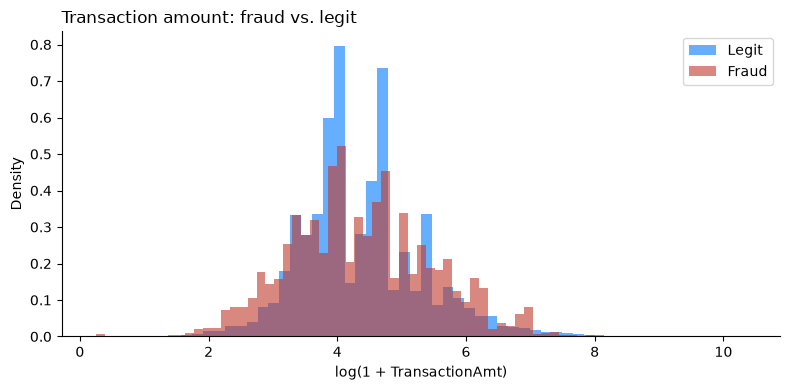

In [10]:
fraud = df_transaction_train[df_transaction_train["isFraud"] == 1]["TransactionAmt"]
legit = df_transaction_train[df_transaction_train["isFraud"] == 0]["TransactionAmt"]

print(pd.DataFrame({"legit": legit.describe(), "fraud": fraud.describe()}).round(2))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(legit), bins=60, density=True, alpha=0.6, label="Legit", color="#007bff")
ax.hist(np.log1p(fraud), bins=60, density=True, alpha=0.6, label="Fraud", color="#c0392b")
ax.set_xlabel("log(1 + TransactionAmt)")
ax.set_ylabel("Density")
ax.set_title("Transaction amount: fraud vs. legit", loc="left")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Note:
On average, the average fradulant credit card amount is larger by $15 more than that of a legitimate purchase. This is important to confirm based off of our distribution because it indicates that fraudulant purchases tend to have hire amounts than that of a legitament purchase. 

# Time patterns | Seeing what is the time in between each transaction

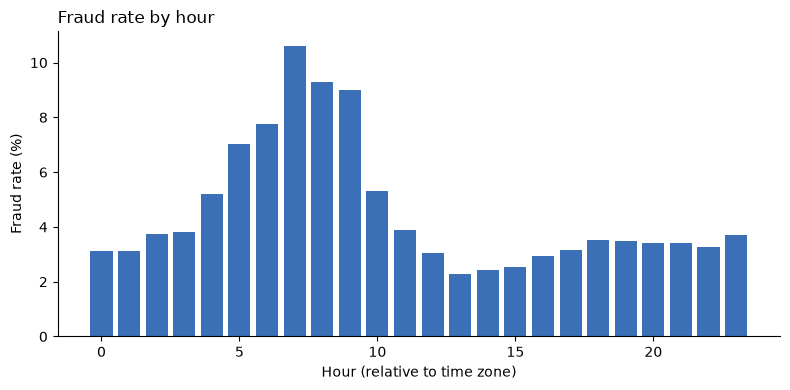

In [11]:
df_transaction_train["day"] = df_transaction_train["TransactionDT"] // 86400 # // 86400 gives us the day...
df_transaction_train["hour"] = (df_transaction_train["TransactionDT"] // 3600) % 24 # gives us hours of the day

hourly = df_transaction_train.groupby("hour")["isFraud"].agg(["size", "mean"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(hourly.index, hourly["mean"] * 100, color="#3b6fb6")
ax.set_xlabel("Hour (relative to time zone)")
ax.set_ylabel("Fraud rate (%)")
ax.set_title("Fraud rate by hour", loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Note
The peak of the bell curve peaks in the morning from 5am to 10am (unkown time zone). Therefore most fraudulant transactions happen early in the morning. 

# Conclusion
#### From our basic analysis on our transaction data we see three things:
1. A lot of nan values contain a large portion of the fraudulant data. Features such as card type, email time, M1 - M9 (name match address) contain much of the fradulant data. Indicating to us that we may need to use the nan values to train our models to be able to classify.
2. Fraud Transaction tend to try and use more money or have higher amounts within their transaction (duhhh...)
3. Most Transaction occur in the morningg

# Numerical (Transaction_train)

In [12]:
import re 

exclude = {"TransactionID", "isFraud", "TransactionDT", "day", "hour"}
num_cols = [c for c in df_transaction_train.select_dtypes(include="number").columns if c not in exclude]

def family(col):
    return re.sub(r"\d+$", "", col)

fraud = df_transaction_train["isFraud"]
overall_rate = fraud.mean() * 100
print(f"{len(num_cols)} numeric columns | overall fraud rate: {overall_rate:.2}%")

377 numeric columns | overall fraud rate: 3.5%


In [17]:
# Missing values and fraud coverage
""" Going to help us understand how much of fraud data is reflected in the numerical data"""
isna = df_transaction_train[num_cols].isna() # give us the list of what is a na value within each of our numerical values
present = ~isna
is_fraud = fraud == 1

nan_table = pd.DataFrame({
    "family": [family(c) for c in num_cols],
    "missing_pct": isna.mean()*100,
    "fraud_coverage": present[is_fraud].mean()*100, # % fraud rows 
    "legit_coverage": present[~is_fraud].mean()*100,
    "rate_present": present.mul(fraud, axis=0).sum() / present.sum()*100,  # .mul multiplies each row by 
    "rate_missing": isna.mul(fraud, axis=0).sum() / isna.sum()*100
}, index=num_cols).round(1)

nan_table.sort_values("missing_pct", ascending=False)

,family,missing_pct,fraud_coverage,legit_coverage,rate_present,rate_missing
dist2,dist,93.6,18.1,5.9,9.9,3.1
D7,D,93.4,28.0,5.8,14.9,2.7
D13,D,89.5,33.1,9.7,11.0,2.6
D14,D,89.5,34.9,9.6,11.6,2.5
D12,D,89.0,36.8,10.0,11.7,2.5
...,...,...,...,...,...,...
V317,V,0.0,100.0,100.0,3.5,16.7
V319,V,0.0,100.0,100.0,3.5,16.7
V318,V,0.0,100.0,100.0,3.5,16.7
card1,card,0.0,100.0,100.0,3.5,NaN


# Note
This is interesting... 

For example for features dist2 and D7, D13, D14, and D12 are missing a large majority of their values. They only contain almost less than 90% of the data. However, as we see in the table, majority of these missing values contain fraud coverage.... 

### Next the best idea is to compare the family features with one another...

In [19]:
nan_table.groupby("family").agg(
    n_cols=("missing_pct", "size"),
    avg_missing=("missing_pct", "mean"),
    avg_fraud_coverage=("fraud_coverage", "mean"),
    avg_rate_present=("rate_present", "mean"),
    avg_rate_missing=("rate_missing", "mean")
    ).round(1).sort_values("avg_missing")

,n_cols,avg_missing,avg_fraud_coverage,avg_rate_present,avg_rate_missing
family,,,,,
C,14,0.0,100.0,3.5,NaN
TransactionAmt,1,0.0,100.0,3.5,NaN
card,4,0.6,99.2,3.5,4.0
addr,2,11.1,62.5,2.5,11.8
V,339,43.1,64.9,5.0,4.9
D,15,58.1,49.6,7.0,3.5
dist,2,76.6,20.6,6.0,3.8


# Note
As we can see from the "family" of each numerical column that have multiple features, the data shows that C, Transaction_AMT, and card have the lowest missing values (or none are missing). However, looking at the other families have high missing values, however as we can see the average rate of present and missing values are very low. Thus may give us signal in our models. 

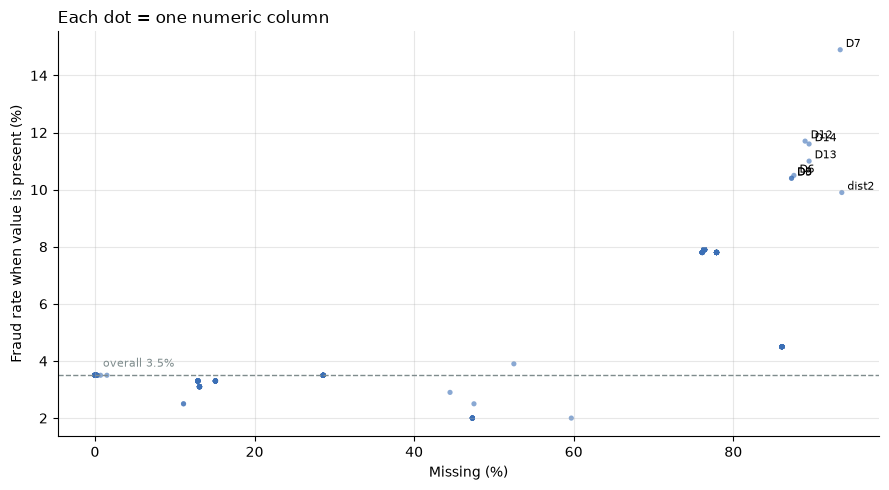

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(nan_table["missing_pct"], nan_table["rate_present"],
           s=14, color="#3b6fb6", alpha=0.6, edgecolor="none")
ax.axhline(overall_rate, color="#7f8c8d", linestyle="--", linewidth=1)
ax.text(1, overall_rate + 0.3, f"overall {overall_rate:.1f}%", fontsize=8, color="#7f8c8d")

for col, row in nan_table.nlargest(8, "rate_present").iterrows():
    ax.annotate(col, (row["missing_pct"], row["rate_present"]),
                fontsize=8, xytext=(4, 2), textcoords="offset points")

ax.set_xlabel("Missing (%)")
ax.set_ylabel("Fraud rate when value is present (%)")
ax.set_title("Each dot = one numeric column", loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

This plot shows, for each numerical feature, how much of its data is missing (x-axis) and the fraud rate among transactions where it has a value (y-axis). The dashed line marks the overall fraud rate of 3.5%. Features above it point to higher-risk transactions when they are filled in.

For example, **D7** is missing for about 93% of transactions, but when it has a value, the fraud rate is 14.9%, roughly 4× the overall rate. Several other **D** features (D12, D13, D14) follow the same pattern: around 90% missing, with fraud rates above 10% when present. **dist2** is similar, at 93.6% missing and a 9.9% fraud rate when present.

This suggests these features are only collected in specific situations, and those situations carry higher fraud risk. Whether the feature has a value at all is therefore a useful signal for classifying fraud. However, these features cover only a minority of fraud cases (D7 has a value for just 28% of them), so they flag one type of fraud rather than fraud in general.

*Note: dots are semi-transparent so overlapping features appear darker. A darker spot means several features share the same missing % and fraud rate, which usually indicates a group of related columns.*


# Missing Value Groups

In [22]:
nan_counts = isna.sum()
group_members = {}
rows = []

for i, (n_missing, cols) in enumerate(sorted(nan_counts.groupby(nan_counts).groups.items()), start=1): # grabs groups of every family and 
    cols = list(cols)
    g = f"G{i:02d}"
    group_members[g] = cols
    has_value = present[cols[0]]

    rows.append({
        "group": g,
        "n_cols": len(cols),
        "families": ", ".join(sorted({family(c) for c in cols})),
        "first_last": cols[0] if len(cols) == 1 else f"{cols[0]} ... {cols[-1]}",
        "missing_pct": n_missing / len(df_transaction_train) * 100,
        "fraud_coverage": has_value[is_fraud].mean() * 100,
        "rate_present": fraud[has_value].mean() * 100,
        "rate_missing": fraud[~has_value].mean() * 100 if (~has_value).any() else np.nan
        })

group_table = pd.DataFrame(rows).set_index("group").round(1)
print(f"{len(group_table)} missing-value groups")
group_table

34 missing-value groups


,n_cols,families,first_last,missing_pct,fraud_coverage,rate_present,rate_missing
group,,,,,,,
G01,16,"C, TransactionAmt, card",TransactionAmt ... C14,0.0,100.0,3.5,NaN
G02,32,V,V279 ... V321,0.0,100.0,3.5,16.7
G03,43,V,V95 ... V137,0.1,99.9,3.5,5.4
G04,12,"D, V",D1 ... V315,0.2,99.8,3.5,3.6
G05,1,card,card3,0.3,99.8,3.5,2.5
G06,1,card,card5,0.7,99.0,3.5,4.9
G07,1,card,card2,1.5,98.0,3.5,4.7
G08,2,addr,addr1 ... addr2,11.1,62.5,2.5,11.8
G09,1,D,D10,12.9,81.2,3.3,5.1


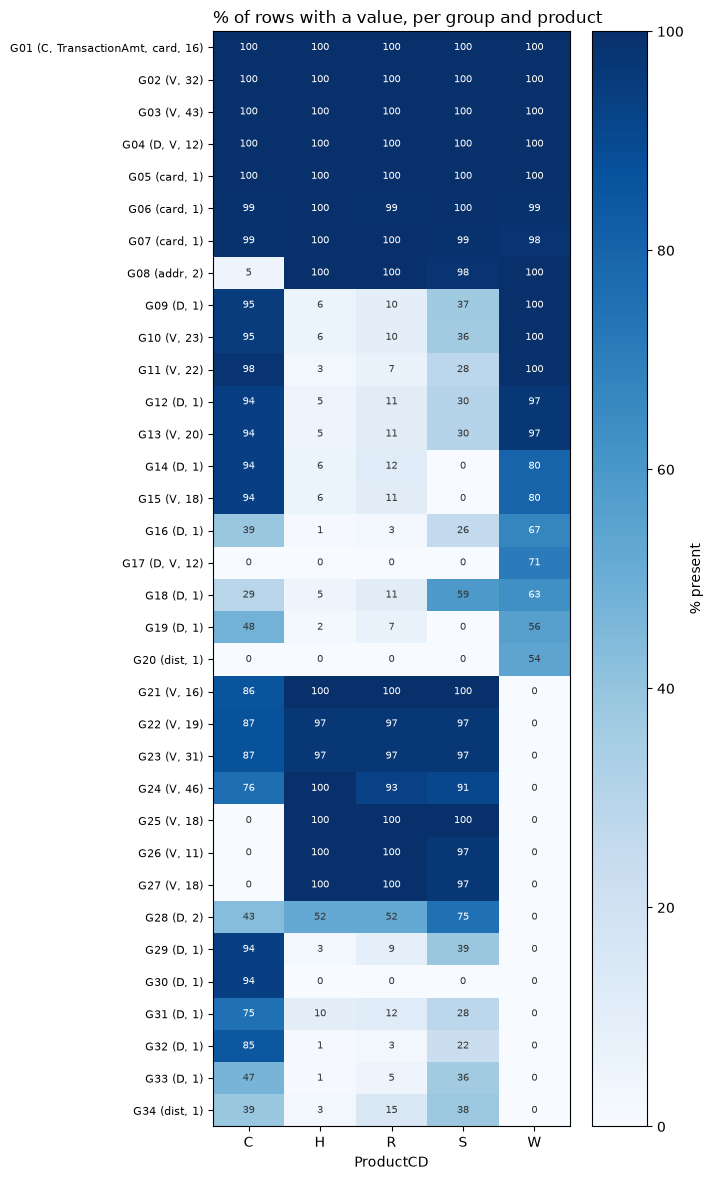

In [24]:
presence_by_product = pd.DataFrame({
    g: df_transaction_train.groupby("ProductCD")[cols[0]].apply(lambda s: s.notna().mean() * 100)
    for g, cols in group_members.items()
}).T.round(0)

fig, ax = plt.subplots(figsize=(7, max(4, len(presence_by_product) * 0.35)))
im = ax.imshow(presence_by_product.values, cmap="Blues", vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(presence_by_product.columns)), presence_by_product.columns)
ax.set_yticks(range(len(presence_by_product.index)),
              [f"{g} ({group_table.loc[g, 'families']}, {group_table.loc[g, 'n_cols']})"
               for g in presence_by_product.index], fontsize=8)

for (r, c), v in np.ndenumerate(presence_by_product.values):
    ax.text(c, r, f"{v:.0f}", ha="center", va="center", fontsize=7,
            color="white" if v > 60 else "#333")

ax.set_xlabel("ProductCD")
ax.set_title("% of rows with a value, per group and product", loc="left")
fig.colorbar(im, ax=ax, label="% present")
plt.tight_layout()
plt.show()


# IMPORTANT Note


# Train Identity exploration

In [14]:
df_identity_train = pd.read_sql("""
    SELECT *
    FROM train_identity
""", conn)

print(f"shape: {df_identity_train.shape}")
print("-" *1000)
print(df_identity_train.info(verbose=True, show_counts=True))

shape: (144233, 41)
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [15]:
cat_set = df_identity_train.select_dtypes(include=["object", "str"]).columns.tolist() 


for col in cat_set:
    print(f"\n---- {col} ----")
    print(f"Unique Couont: {df_identity_train[col].nunique()}")
    print(df_identity_train[col].value_counts())


---- id_12 ----
Unique Couont: 2
id_12
NotFound    123025
Found        21208
Name: count, dtype: int64

---- id_15 ----
Unique Couont: 3
id_15
Found      67728
New        61612
Unknown    11645
Name: count, dtype: int64

---- id_16 ----
Unique Couont: 2
id_16
Found       66324
NotFound    63016
Name: count, dtype: int64

---- id_23 ----
Unique Couont: 3
id_23
IP_PROXY:TRANSPARENT    3489
IP_PROXY:ANONYMOUS      1071
IP_PROXY:HIDDEN          609
Name: count, dtype: int64

---- id_27 ----
Unique Couont: 2
id_27
Found       5155
NotFound      14
Name: count, dtype: int64

---- id_28 ----
Unique Couont: 2
id_28
Found    76232
New      64746
Name: count, dtype: int64

---- id_29 ----
Unique Couont: 2
id_29
Found       74926
NotFound    66052
Name: count, dtype: int64

---- id_30 ----
Unique Couont: 75
id_30
Windows 10          21155
Windows 7           13110
iOS 11.2.1           3722
iOS 11.1.2           3699
Android 7.0          2871
                    ...  
func                   10
iOS

# Model Preperation

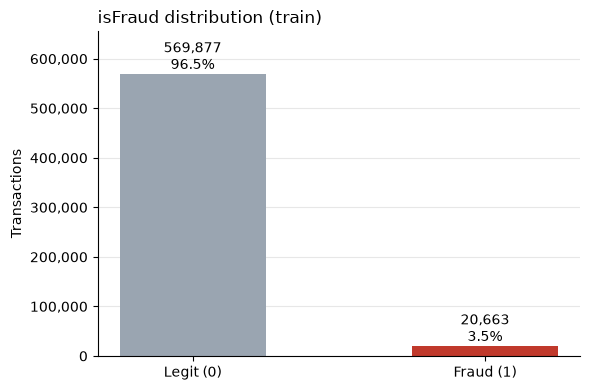

In [16]:
counts = df_transaction_train.isFraud.value_counts().sort_index()

pct = counts / counts.sum()*100
labels = ["Legit (0)", "Fraud (1)"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts.values, color=["#9aa5b1", "#c0392b"], width=0.5)

for bar, n, p in zip(bars, counts.values, pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{n:,}\n{p:.1f}%", ha="center", va="bottom", fontsize=10)

ax.set_title("isFraud distribution (train)", loc="left", fontsize=12)
ax.set_ylabel("Transactions")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True) 
ax.set_ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.show()


# Rises Problem
Our target variable (isFraud) is imbalanced. When training the model, the model will be trained and shaped for this specific distribution. Therefore, not allowing us to generalize our model to classify whether a transaction is fraudulant or not. 

# Notes for underfit....
This will underfit our data for multiple reasons. One the model won't be able to generalize it's shape or model to classify Legit and Fraud transactions. 

**Helpful** What is helpful about this data set is the features that weere engineered... id (identity) data which aren't specified but provided are each id is a count of what IP, IPS, Proxy, etc. the transaction occured. This is helpful because it helps us see how many of these transactions came from a specific spot

**Helpful** Vesta-engineered features (V_{id}) similar to the Id feature, it also identifies the frequency of an email's, IP or address that the transaction occured within a 24-hr period. 



# Narrow Down Our Analysis

### Baseline: Logistic Regression

### Unsupervised Learning Clustering, DBSCAN

### Comparison: XGBoost & RandomForrest